In [14]:
!pip install ultralytics -q

In [15]:
# =========================
# CELDA 1 - SETUP CORRECTO
# =========================

!pip install ultralytics -q

from google.colab import drive
from pathlib import Path
import os
import shutil
import zipfile
import torch
from ultralytics import YOLO

# =========================
# MONTAR DRIVE
# =========================

drive.mount("/content/drive")

# =========================
# RUTAS DEL PROYECTO
# =========================

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/ModeloEntrenado")

ZIP_NAME = "insect_parts_dataset_combined.zip"
ZIP_PATH = DRIVE_PROJECT_DIR / ZIP_NAME

EXTRACT_PATH = Path("/content/insect_dataset")

FINAL_MODELS_DIR = DRIVE_PROJECT_DIR / "final_models"
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

YOLO_EPOCHS = 50
YOLO_BATCH = 8
IMG_SIZE_YOLO = 640

# True = entrenar YOLO desde cero
# False = cargar YOLO ya entrenado desde Drive
TRAIN_YOLO = True

# =========================
# VERIFICAR GPU
# =========================

print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
    YOLO_DEVICE = 0
else:
    raise RuntimeError(
        "NO HAY GPU ACTIVA. Antes de correr esto ve a: "
        "Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU T4. "
        "Luego guarda y vuelve a correr desde esta celda."
    )

# =========================
# VERIFICAR ARCHIVOS
# =========================

if not DRIVE_PROJECT_DIR.exists():
    raise FileNotFoundError(f"No existe la carpeta del proyecto: {DRIVE_PROJECT_DIR}")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"No existe el ZIP del dataset: {ZIP_PATH}")

print("Carpeta de proyecto en Drive:", DRIVE_PROJECT_DIR)
print("Ruta del ZIP:", ZIP_PATH)
print("Ruta final de modelos:", FINAL_MODELS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA disponible: True
GPU detectada: Tesla T4
Carpeta de proyecto en Drive: /content/drive/MyDrive/ModeloEntrenado
Ruta del ZIP: /content/drive/MyDrive/ModeloEntrenado/insect_parts_dataset_combined.zip
Ruta final de modelos: /content/drive/MyDrive/ModeloEntrenado/final_models


In [16]:
def find_file(filename, search_roots):
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        direct = root / filename
        if direct.exists():
            return direct

        matches = list(root.rglob(filename))
        if matches:
            return matches[0]

    return None


ZIP_PATH = find_file(
    ZIP_NAME,
    [
        DRIVE_PROJECT_DIR,
        Path("/content/drive/MyDrive"),
        Path("/content")
    ]
)

if ZIP_PATH is None:
    raise FileNotFoundError(
        f"No encontré {ZIP_NAME}. "
        "Verifica que esté en la carpeta ModeloEntrenado o súbelo a Colab."
    )

print("ZIP encontrado en:", ZIP_PATH)

if EXTRACT_PATH.exists():
    shutil.rmtree(EXTRACT_PATH)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset descomprimido en:", EXTRACT_PATH)

data_yaml_files = list(EXTRACT_PATH.rglob("data.yaml"))

if not data_yaml_files:
    raise FileNotFoundError("No se encontró data.yaml dentro del ZIP.")

DATA_YAML = data_yaml_files[0]
DATASET_ROOT = DATA_YAML.parent

print("data.yaml:", DATA_YAML)
print("Dataset root:", DATASET_ROOT)

ZIP encontrado en: /content/drive/MyDrive/ModeloEntrenado/insect_parts_dataset_combined.zip
Dataset descomprimido en: /content/insect_dataset
data.yaml: /content/insect_dataset/insect_parts_dataset_combined/data.yaml
Dataset root: /content/insect_dataset/insect_parts_dataset_combined


In [17]:
for split in ["train", "valid", "test"]:
    images_dir = DATASET_ROOT / split / "images"
    labels_dir = DATASET_ROOT / split / "labels"

    image_count = len(list(images_dir.glob("*"))) if images_dir.exists() else 0
    label_count = len(list(labels_dir.glob("*.txt"))) if labels_dir.exists() else 0

    print(f"{split}:")
    print("  imágenes:", image_count)
    print("  labels:", label_count)

print("\nContenido de data.yaml:")
print(DATA_YAML.read_text())

train:
  imágenes: 231
  labels: 231
valid:
  imágenes: 66
  labels: 66
test:
  imágenes: 34
  labels: 34

Contenido de data.yaml:
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- antennae
- body
- insect
- legs
- mouthpart
- wings



In [19]:
from pathlib import Path
import shutil
from ultralytics import YOLO

# =========================
# ENTRENAR YOLO
# =========================

YOLO_RUNS_DIR = Path("/content/yolo_runs")
YOLO_RUN_NAME = "insect_parts_yolov8n"

if TRAIN_YOLO:
    yolo_model = YOLO("yolov8n.pt")

    yolo_results = yolo_model.train(
        data=str(DATA_YAML),
        epochs=YOLO_EPOCHS,
        imgsz=IMG_SIZE_YOLO,
        batch=YOLO_BATCH,
        project=str(YOLO_RUNS_DIR),      # ESTA LÍNEA ES LA CLAVE
        name=YOLO_RUN_NAME,
        exist_ok=True,
        patience=10,
        device=YOLO_DEVICE
    )

    # Tomar la ruta real donde Ultralytics guardó el entrenamiento
    YOLO_BEST_PATH = Path(yolo_results.save_dir) / "weights" / "best.pt"

else:
    YOLO_BEST_PATH = FINAL_MODELS_DIR / "best_yolo_insect_parts.pt"

# =========================
# VALIDAR QUE EXISTE
# =========================

if not YOLO_BEST_PATH.exists():
    raise FileNotFoundError(f"No se encontró el modelo YOLO entrenado en: {YOLO_BEST_PATH}")

print("Mejor modelo YOLO:")
print(YOLO_BEST_PATH)

# =========================
# COPIAR MODELO FINAL A DRIVE
# =========================

YOLO_FINAL_PATH = FINAL_MODELS_DIR / "best_yolo_insect_parts.pt"

shutil.copyfile(YOLO_BEST_PATH, YOLO_FINAL_PATH)

print("\nYOLO entrenado y copiado correctamente a Drive:")
print(YOLO_FINAL_PATH)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/insect_dataset/insect_parts_dataset_combined/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=insect_parts_yolov8n, nbs=64, nms=False, opset=None, optimize=False, opti

In [20]:
from pathlib import Path
import shutil
from ultralytics import YOLO

# =========================
# RECUPERAR YOLO YA ENTRENADO
# =========================

FINAL_MODELS_DIR = Path("/content/drive/MyDrive/ModeloEntrenado/final_models")
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Buscar el run más reciente de YOLO
yolo_runs = sorted(
    Path("/content/runs/detect").glob("insect_parts_yolov8n*"),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

print("Runs encontrados:")
for r in yolo_runs:
    print(r)

if len(yolo_runs) == 0:
    raise FileNotFoundError("No encontré ningún entrenamiento YOLO en /content/runs/detect")

# Tomar el más reciente
YOLO_BEST_PATH = yolo_runs[0] / "weights" / "best.pt"

if not YOLO_BEST_PATH.exists():
    raise FileNotFoundError(f"No existe el best.pt en: {YOLO_BEST_PATH}")

print("\nModelo YOLO encontrado:")
print(YOLO_BEST_PATH)

# Cargar modelo
best_yolo = YOLO(str(YOLO_BEST_PATH))

# Copiar a Drive
YOLO_FINAL_PATH = FINAL_MODELS_DIR / "best_yolo_insect_parts.pt"
shutil.copy(YOLO_BEST_PATH, YOLO_FINAL_PATH)

print("\nYOLO copiado correctamente a Drive:")
print(YOLO_FINAL_PATH)

Runs encontrados:
/content/runs/detect/insect_parts_yolov8n-3
/content/runs/detect/insect_parts_yolov8n-2
/content/runs/detect/insect_parts_yolov8n

Modelo YOLO encontrado:
/content/runs/detect/insect_parts_yolov8n-3/weights/best.pt

YOLO copiado correctamente a Drive:
/content/drive/MyDrive/ModeloEntrenado/final_models/best_yolo_insect_parts.pt



image 1/66 /content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000281.jpg: 640x640 2 bodys, 1 insect, 2 legss, 12.9ms
image 2/66 /content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000285.jpg: 640x640 1 antennae, 1 body, 1 insect, 3 legss, 2 wingss, 22.7ms
image 3/66 /content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000286.jpg: 640x640 1 antennae, 1 insect, 7 legss, 1 wings, 12.3ms
image 4/66 /content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000290.jpg: 640x640 2 antennaes, 1 body, 1 insect, 3 legss, 1 mouthpart, 1 wings, 7.2ms
image 5/66 /content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000292.jpg: 640x640 2 insects, 4 legss, 7.2ms
image 6/66 /content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000300.jpg: 640x640 1 body, 1 insect, 6 legss, 7.2ms
image 7/66 /content/

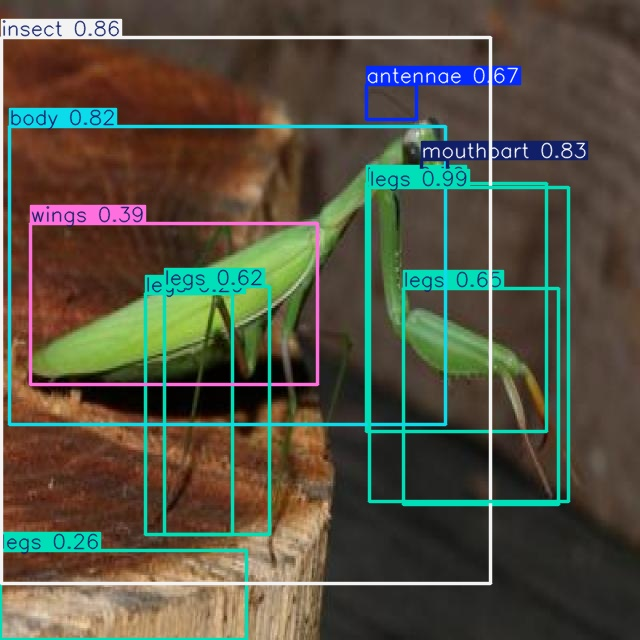

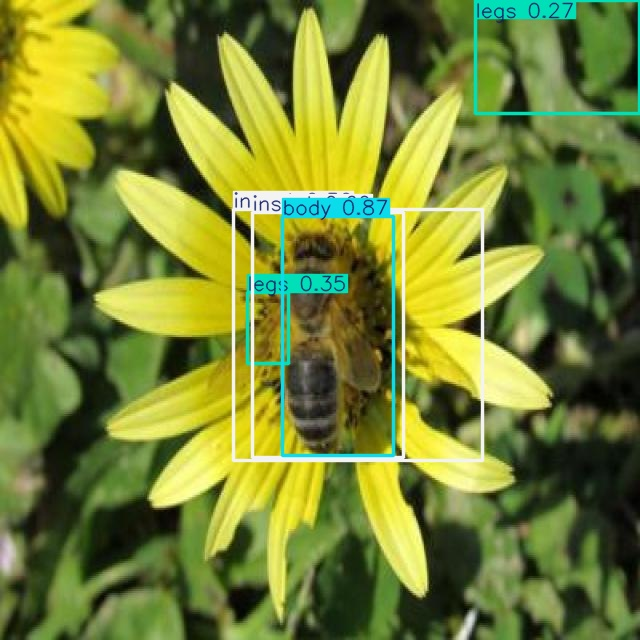

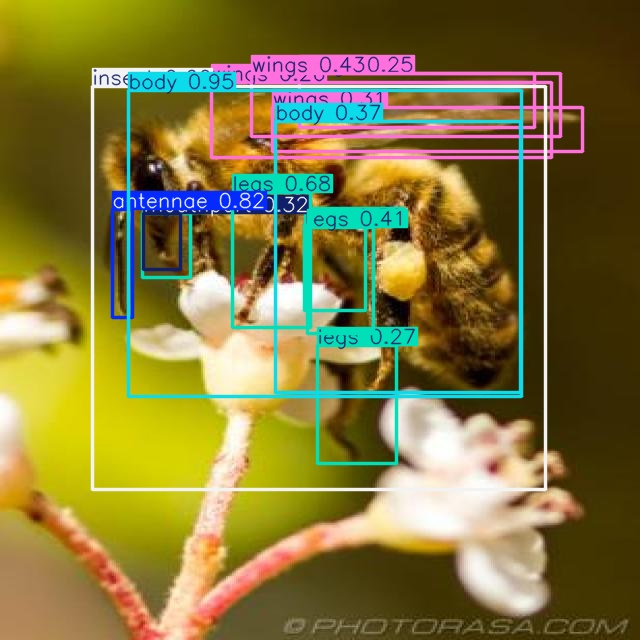

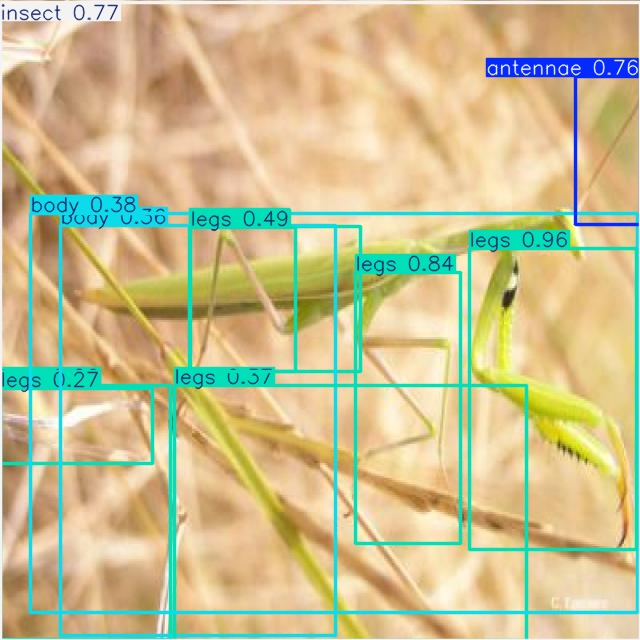

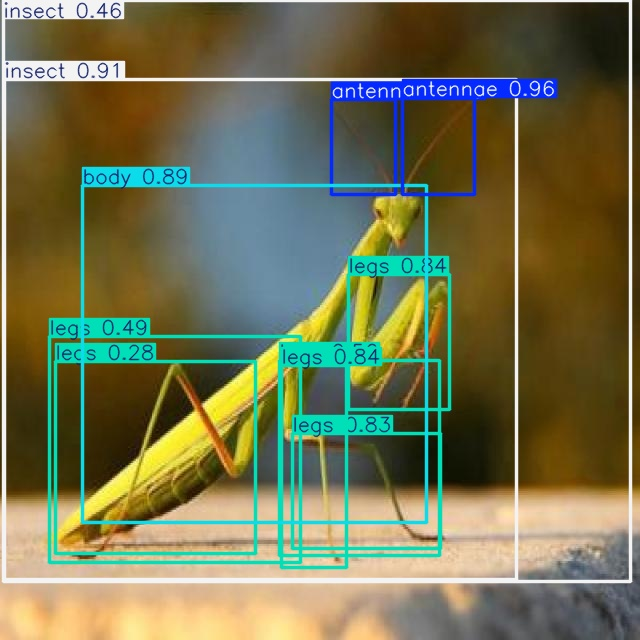

In [23]:
PREVIEW_PROJECT = Path("/content/yolo_preview")
PREVIEW_NAME = "valid_predictions"

pred_results = best_yolo.predict(
    source=str(DATASET_ROOT / "valid" / "images"),
    imgsz=IMG_SIZE_YOLO,
    conf=0.25,
    save=True,
    project=str(PREVIEW_PROJECT),
    name=PREVIEW_NAME,
    exist_ok=True
)

pred_dir = PREVIEW_PROJECT / PREVIEW_NAME

print("Predicciones guardadas en:", pred_dir)

shown = 0
for img_path in pred_dir.glob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        display(IPImage(filename=str(img_path)))
        shown += 1

    if shown >= 5:
        break

In [24]:
def safe_copy(src, dst):
    src = Path(src)
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)

    if not src.exists():
        raise FileNotFoundError(f"No existe el archivo origen: {src}")

    if dst.exists() and src.resolve() == dst.resolve():
        print("Ya está en el destino:", dst)
        return dst

    shutil.copy2(src, dst)
    print("Copiado:", dst)
    return dst


YOLO_FINAL_PATH = FINAL_MODELS_DIR / "best_yolo_insect_parts.pt"
safe_copy(YOLO_BEST_PATH, YOLO_FINAL_PATH)

# Guardar algunos artefactos útiles del entrenamiento
ARTIFACTS_DIR = FINAL_MODELS_DIR / "yolo_training_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

YOLO_RUN_DIR = YOLO_BEST_PATH.parents[1]

for filename in [
    "args.yaml",
    "results.csv",
    "results.png",
    "labels.jpg",
    "confusion_matrix.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png"
]:
    src = YOLO_RUN_DIR / filename
    if src.exists():
        safe_copy(src, ARTIFACTS_DIR / filename)

# Crear backup ZIP de modelos finales
backup_path = "/content/final_models_backup"
shutil.make_archive(backup_path, "zip", FINAL_MODELS_DIR)

safe_copy(
    Path(backup_path + ".zip"),
    DRIVE_PROJECT_DIR / "final_models_backup.zip"
)

print("\nYOLO guardado correctamente.")
print("Modelo YOLO final:", YOLO_FINAL_PATH)
print("Backup:", DRIVE_PROJECT_DIR / "final_models_backup.zip")

Copiado: /content/drive/MyDrive/ModeloEntrenado/final_models/best_yolo_insect_parts.pt
Copiado: /content/drive/MyDrive/ModeloEntrenado/final_models/yolo_training_artifacts/args.yaml
Copiado: /content/drive/MyDrive/ModeloEntrenado/final_models/yolo_training_artifacts/results.csv
Copiado: /content/drive/MyDrive/ModeloEntrenado/final_models/yolo_training_artifacts/results.png
Copiado: /content/drive/MyDrive/ModeloEntrenado/final_models/yolo_training_artifacts/labels.jpg
Copiado: /content/drive/MyDrive/ModeloEntrenado/final_models/yolo_training_artifacts/confusion_matrix.png
Copiado: /content/drive/MyDrive/ModeloEntrenado/final_models_backup.zip

YOLO guardado correctamente.
Modelo YOLO final: /content/drive/MyDrive/ModeloEntrenado/final_models/best_yolo_insect_parts.pt
Backup: /content/drive/MyDrive/ModeloEntrenado/final_models_backup.zip


In [25]:
from pathlib import Path
import shutil
from ultralytics import YOLO

# =========================
# CORRECCIÓN FINAL YOLO
# NO ENTRENA, SOLO GUARDA EL MODELO CORRECTO
# =========================

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/ModeloEntrenado")
FINAL_MODELS_DIR = DRIVE_PROJECT_DIR / "final_models"
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Este es el run correcto de la celda [19]
YOLO_RUN_DIR = Path("/content/yolo_runs/insect_parts_yolov8n")
YOLO_BEST_PATH = YOLO_RUN_DIR / "weights" / "best.pt"

if not YOLO_BEST_PATH.exists():
    raise FileNotFoundError(
        f"No existe el YOLO correcto en: {YOLO_BEST_PATH}. "
        "No corras esta celda hasta que la celda de entrenamiento haya terminado bien."
    )

# Copiar modelo final correcto a Drive
YOLO_FINAL_PATH = FINAL_MODELS_DIR / "best_yolo_insect_parts.pt"
shutil.copy2(YOLO_BEST_PATH, YOLO_FINAL_PATH)

# Cargar desde Drive para confirmar que sí funciona
best_yolo = YOLO(str(YOLO_FINAL_PATH))

print("YOLO correcto guardado en Drive:")
print(YOLO_FINAL_PATH)

print("\nFuente real del modelo:")
print(YOLO_BEST_PATH)

# =========================
# GUARDAR ARTEFACTOS DEL MISMO ENTRENAMIENTO
# =========================

ARTIFACTS_DIR = FINAL_MODELS_DIR / "yolo_training_artifacts"

if ARTIFACTS_DIR.exists():
    shutil.rmtree(ARTIFACTS_DIR)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

for filename in [
    "args.yaml",
    "results.csv",
    "results.png",
    "labels.jpg",
    "confusion_matrix.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png"
]:
    src = YOLO_RUN_DIR / filename
    if src.exists():
        shutil.copy2(src, ARTIFACTS_DIR / filename)
        print("Artefacto copiado:", filename)

# Crear backup zip actualizado
backup_base = "/content/final_models_backup"
backup_zip = shutil.make_archive(backup_base, "zip", FINAL_MODELS_DIR)

shutil.copy2(
    backup_zip,
    DRIVE_PROJECT_DIR / "final_models_backup.zip"
)

print("\nBackup actualizado:")
print(DRIVE_PROJECT_DIR / "final_models_backup.zip")

print("\nLISTO. Este es el YOLO final correcto.")

YOLO correcto guardado en Drive:
/content/drive/MyDrive/ModeloEntrenado/final_models/best_yolo_insect_parts.pt

Fuente real del modelo:
/content/yolo_runs/insect_parts_yolov8n/weights/best.pt
Artefacto copiado: args.yaml
Artefacto copiado: results.csv
Artefacto copiado: results.png
Artefacto copiado: labels.jpg
Artefacto copiado: confusion_matrix.png

Backup actualizado:
/content/drive/MyDrive/ModeloEntrenado/final_models_backup.zip

LISTO. Este es el YOLO final correcto.
